In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(deliveries.shape)
matches.head()

(1095, 20)
(172943, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [21]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [ ]:
print(matches.isnull().sum())

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [13]:

matches = matches.dropna(subset=['winner'])
matches['city'] = matches['city'].fillna('Unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('Unknown')
print(matches.shape)

(1090, 20)


/tmp/ipykernel_1091/3874128851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.values, y=win_counts.index, palette='rocket')


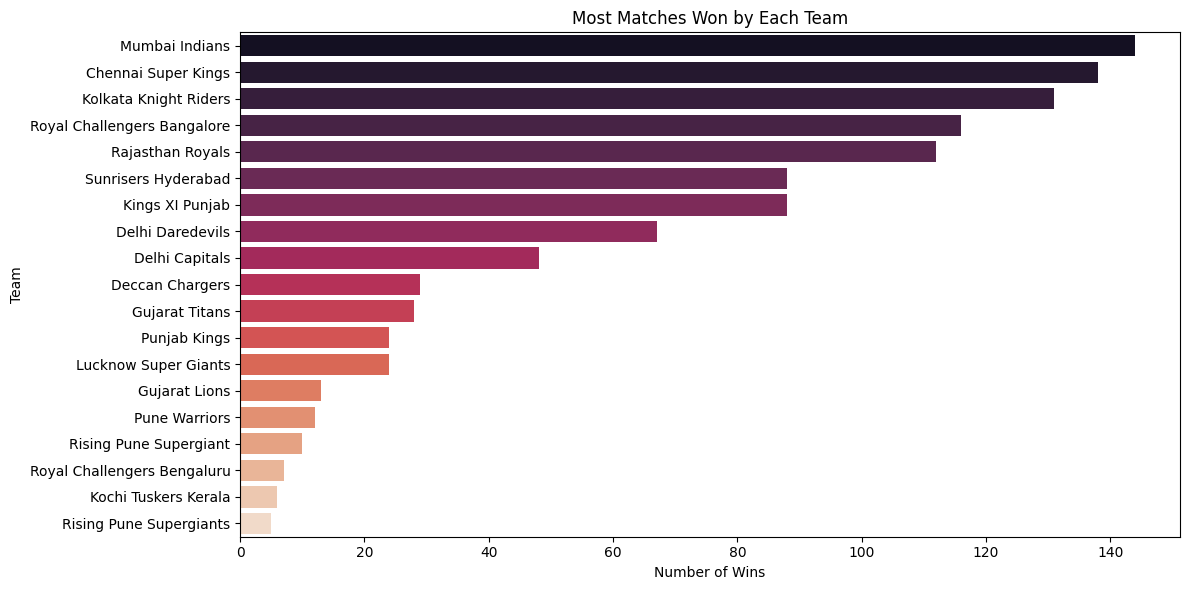

In [16]:
plt.figure(figsize=(12,6))
win_counts = matches['winner'].value_counts()
sns.barplot(x=win_counts.values, y=win_counts.index, palette='rocket')
plt.title('Most Matches Won by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

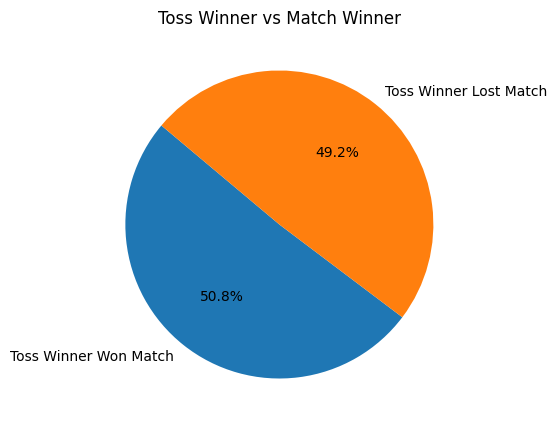

In [20]:
tosswin = matches[matches['toss_winner'] == matches['winner']]
tossloss = matches[matches['toss_winner'] != matches['winner']]

labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']
sizes = [len(tosswin), len(tossloss)]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Toss Winner vs Match Winner')
plt.show()

/tmp/ipykernel_1091/2062835978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma', legend="false" )


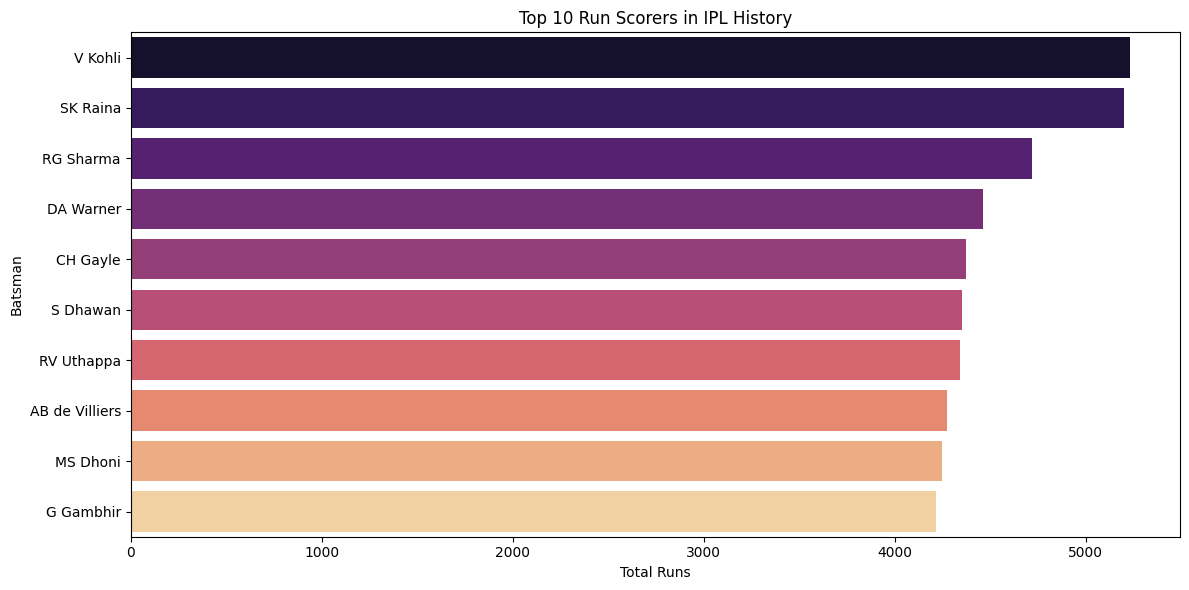

In [27]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma', legend="false" )
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1091/55263079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='coolwarm')


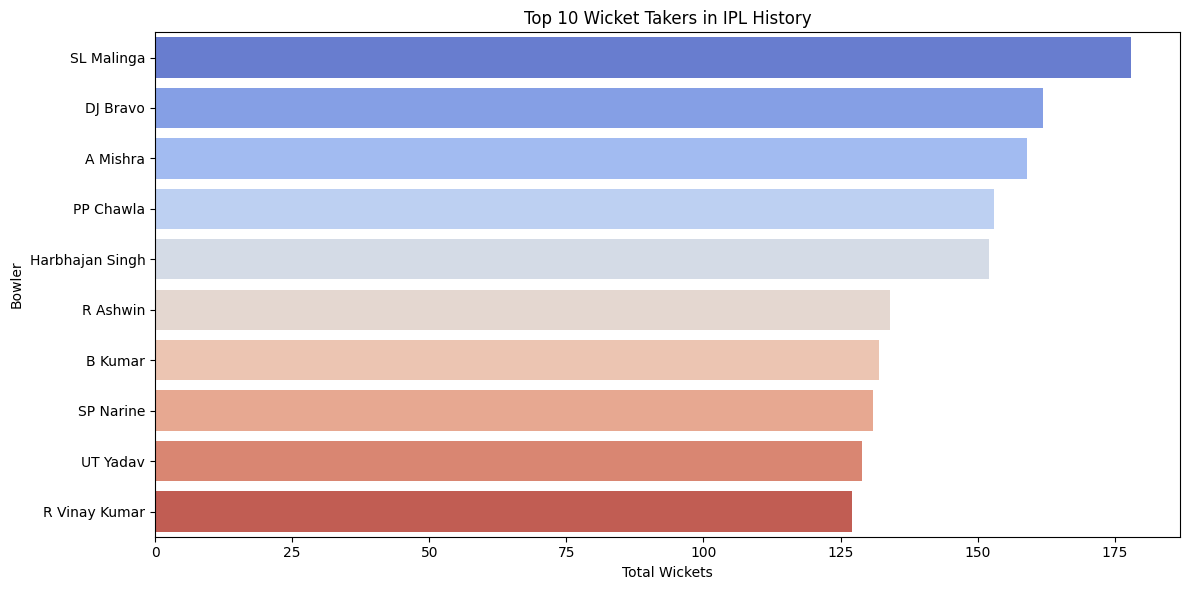

In [ ]:
wickets = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='coolwarm')
plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

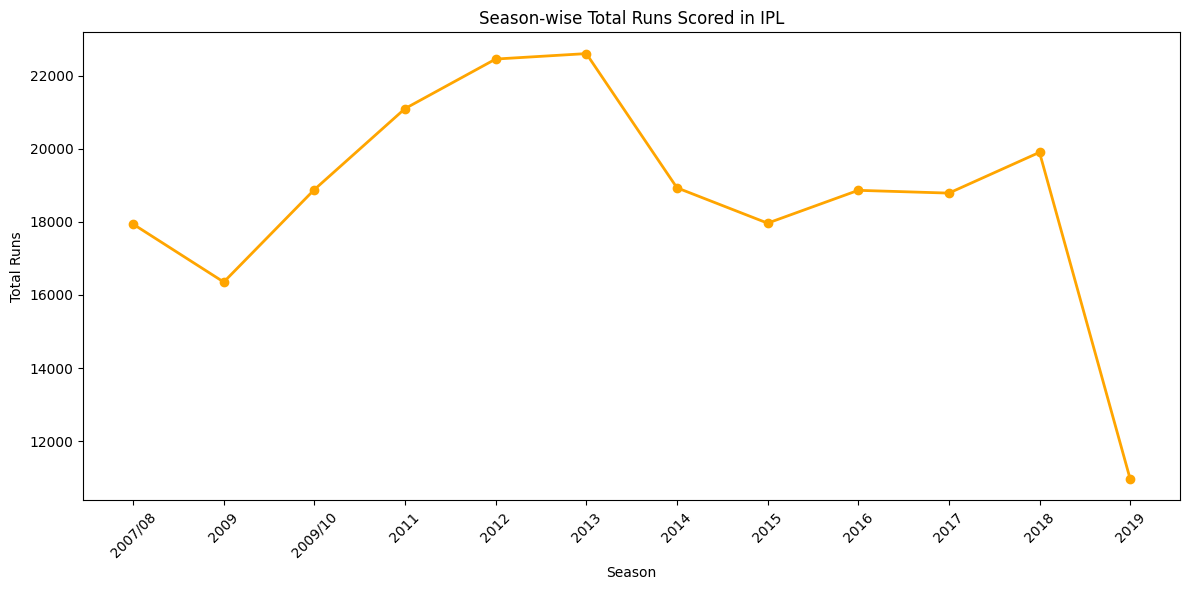

In [ ]:
season_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
season_runs = season_runs.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum()

plt.plot(season_total.index, season_total.values, marker='o', color='orange', linewidth=2)
plt.title('Season-wise Total Runs Scored in IPL')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

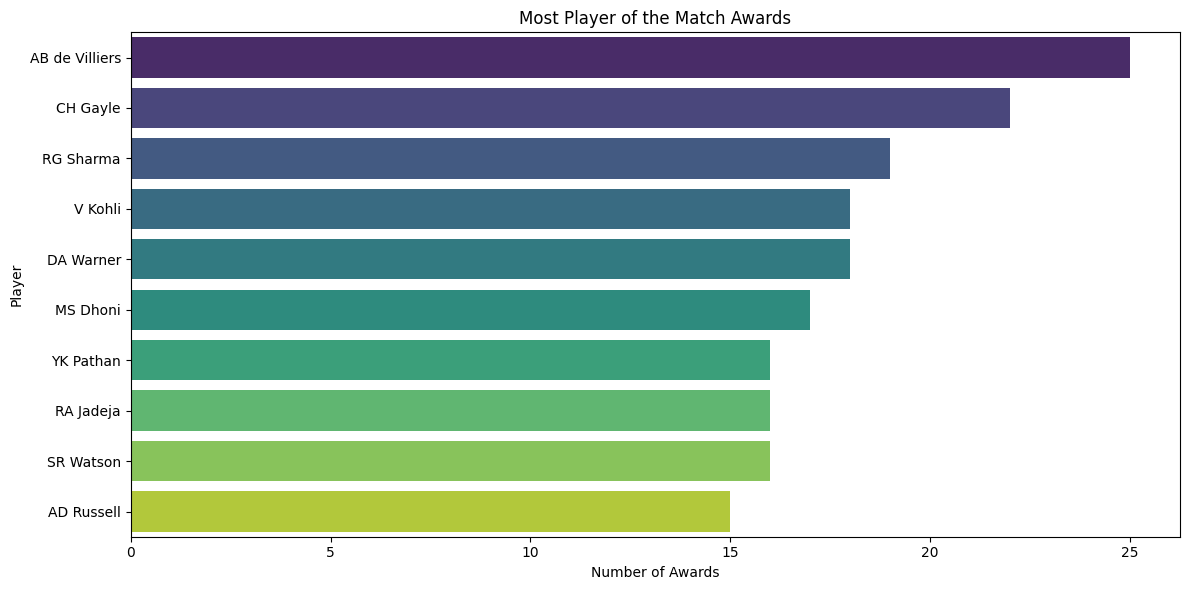

In [28]:
top_players = matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_players.values, y=top_players.index, hue=top_players.index, palette='viridis', legend=False)
plt.title('Most Player of the Match Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

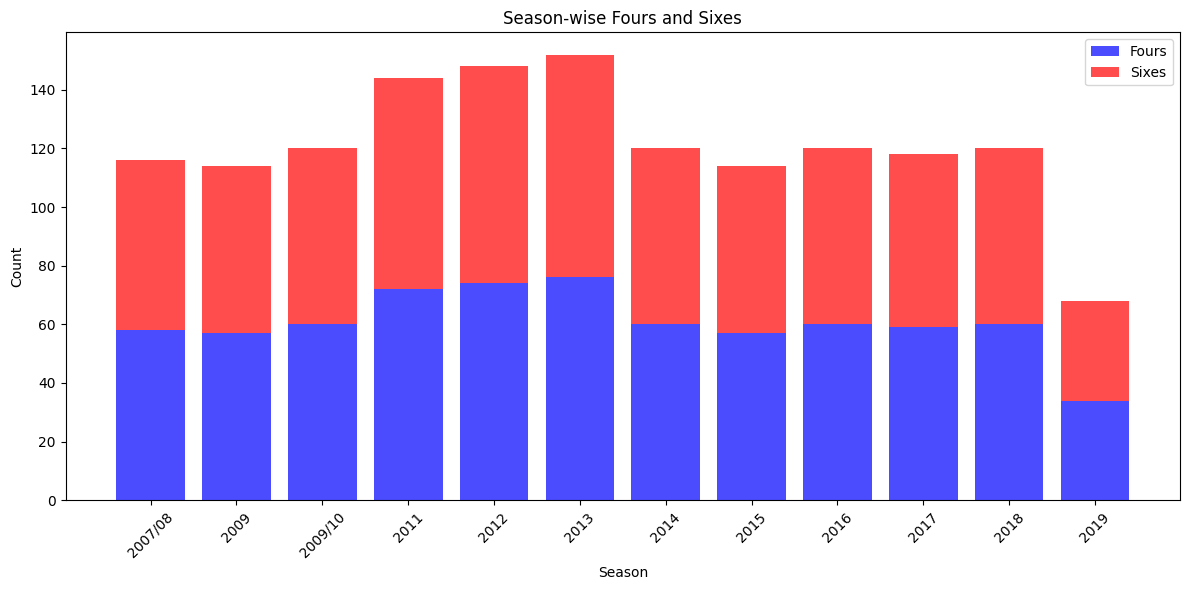

In [29]:
fours = deliveries[deliveries['batsman_runs']==4].groupby('match_id')['batsman_runs'].count().reset_index()
sixes = deliveries[deliveries['batsman_runs']==6].groupby('match_id')['batsman_runs'].count().reset_index()

fours = fours.merge(matches[['id','season']], left_on='match_id', right_on='id')
sixes = sixes.merge(matches[['id','season']], left_on='match_id', right_on='id')

season_fours = fours.groupby('season')['batsman_runs'].count()
season_sixes = sixes.groupby('season')['batsman_runs'].count()

plt.figure(figsize=(12,6))
plt.bar(season_fours.index, season_fours.values, label='Fours', color='blue', alpha=0.7)
plt.bar(season_sixes.index, season_sixes.values, label='Sixes', color='red', alpha=0.7, bottom=season_fours.values)
plt.title('Season-wise Fours and Sixes')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

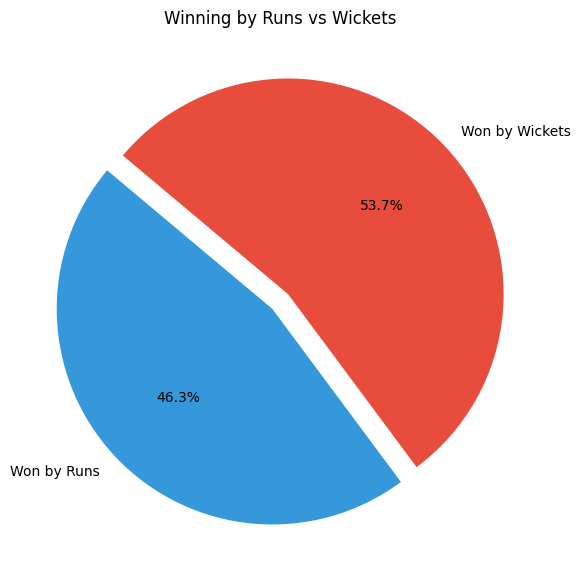

In [30]:
win_by_runs = matches[matches['result'] == 'runs']['result'].count()
win_by_wickets = matches[matches['result'] == 'wickets']['result'].count()

labels = ['Won by Runs', 'Won by Wickets']
sizes = [win_by_runs, win_by_wickets]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#3498DB','#E74C3C'], startangle=140,
        explode=(0.05, 0.05))
plt.title('Winning by Runs vs Wickets')
plt.show()

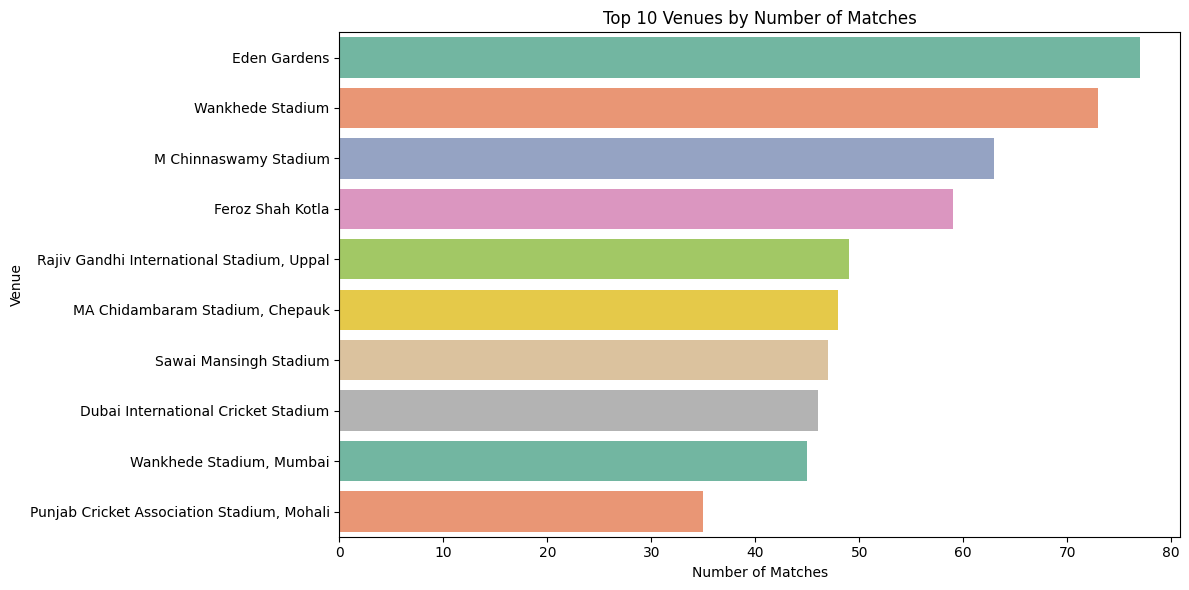

In [31]:
top_venues = matches['venue'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_venues.values, y=top_venues.index,
            hue=top_venues.index, palette='Set2', legend=False)
plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

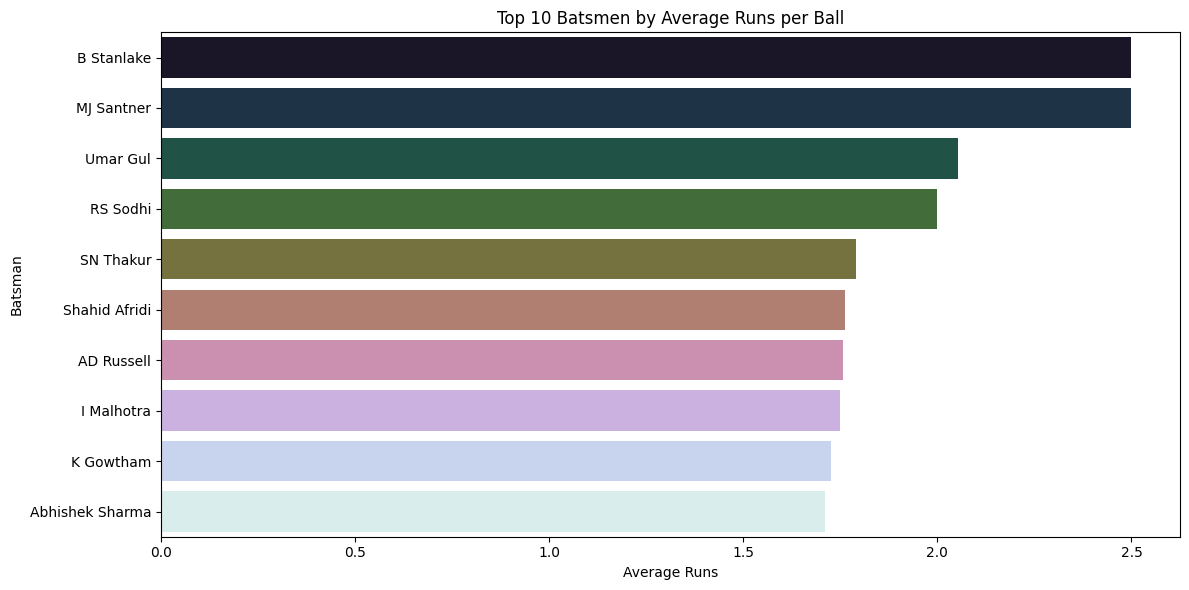

In [32]:
avg_runs = deliveries.groupby('batter')['batsman_runs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_runs.values, y=avg_runs.index,
            hue=avg_runs.index, palette='cubehelix', legend=False)
plt.title('Top 10 Batsmen by Average Runs per Ball')
plt.xlabel('Average Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()